In [ ]:
import sys
import time
from dataclasses import replace
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from eos import alphabag, ccdm, njl, vmit
from eos.ccdm.table import rows_from_result as ccdm_rows_from_result
from eos.general.figure_style import (LABELS, OKAB_CAT, log_decades,
                                      panel_label, paper_grid,
                                      particle_style)
from eos.general.physics_constants import hc3
from eos.general.table_io import matrix_from_rows
from eos.ccdm.couplings import vector_coupling
from scipy.optimize import root

from eos.ccdm.thermodynamics import (dielectric, glue_potential,
                                     state_at, thermo_from_mu)
from eos.njl import vector_self_energy
from eos.njl.table import rows_from_result as njl_rows_from_result

# Name -> package. Every model exposes the same entry points under the same
# names — `Parameters`, `SpeciesFlags`, `eos_point`, `eos_table` — so one loop
# body serves all four. `rows_from_result` is the one that is not uniform:
# `vmit` and `alphabag` re-export it from the package, `njl` and `ccdm` leave it
# in their `table` module, so it is looked up here once rather than branched on
# inside the loop.
MODELS = {"vmit": vmit, "alphabag": alphabag, "njl": njl, "ccdm": ccdm}
ROWS_FROM_RESULT = {"vmit": vmit.rows_from_result,
                    "alphabag": alphabag.rows_from_result,
                    "njl": njl_rows_from_result,
                    "ccdm": ccdm_rows_from_result}

## One T = 0 beta-equilibrium line, per model

The quark counterpart of `hadronic_timing`: four models of deconfined matter
driven through the same public entry points, in the same mode, on the same
density grid, and timed the same way.

The sectors are the six names of CLAUDE.md section 4, spelled identically in
every model, plus `csc` — the pairing sector, which exists only where the
functional has it. `vmit` and `alphabag` carry no such field, so passing it
would be a `TypeError`, which is this notebook's own bug and not a model
refusing anything; the flag is therefore added per model rather than shared.

`muons` is off for all four, and that is a gap rather than a choice: `njl` and
`ccdm` wire the muon family, `vmit` and `alphabag` do not and raise if asked.
One shared value is what keeps all four models in the same figures.

In [ ]:
# The six section-4 names, identical in every model.
SPECIES = dict(hyperons=False, deltas=False, muons=False,
               thermal_mesons=False, thermal_neutrinos=False, photons=False)

# `csc` only where the pairing sector is in the functional. False everywhere:
# this notebook is unpaired quark matter.
CSC = {"njl": False, "ccdm": False}

# The published set each model is driven at; None = Parameters.default().
#   vmit, alphabag  ship exactly one set each, so there is nothing to name.
#   njl             "rkh" is the shipped default — the set every verified number
#                   in the model's documentation was produced at and the one
#                   test/baseline is frozen at.
#   ccdm            "baseline" is the specification's own baseline set, likewise
#                   the shipped default. Its deconfinement onset sits just below
#                   1 fm^-3, well inside the grid below, which is the point:
#                   the densities underneath it come back unsolved and that is
#                   physics about the model, not a solver failure.
PARAMETER_SET = {"vmit": None, "alphabag": None,
                 "njl": "rkh", "ccdm": "baseline"}

# 0.1 to 1.6 fm^-3. The top is a few times saturation, which is where a hybrid
# star's quark core lives; the bottom is deliberately below any of these phases
# being the physical state, so `ccdm`'s onset shows up as refusals in the count
# rather than being hidden by a grid chosen to flatter it.
N_B = np.linspace(0.1, 1.6, 60)
T = 0.0

TABLES = {}          # {model: rows}, read by every figure below
PARAMS = {}          # {model: par}, read by the effective-mass figure

print(f"=== one line, beta_eq_neutrinoless, T = {T} MeV, "
      f"{len(N_B)} points from {N_B[0]:.3f} to {N_B[-1]:.3f} fm^-3 ===")

for name, module in MODELS.items():
    published = PARAMETER_SET[name]
    par = (module.Parameters.default() if published is None
           else module.Parameters.named(published))

    # A model that does not have one of the selected sectors refuses — at flag
    # construction where the sector is absent from the functional, inside
    # `eos_point` where the mode is not one this phase has. Both are the
    # library's contract working, so they are printed and skipped, never dressed
    # up as a result. `TypeError` is deliberately not caught: an unexpected
    # keyword is this notebook's own bug.
    try:
        species = module.SpeciesFlags(
            **SPECIES, **({"csc": CSC[name]} if name in CSC else {}))

        start = time.perf_counter()
        point = module.eos_point(par, "beta_eq_neutrinoless", species,
                                 n_B=float(N_B[0]), T=T)
        first_s = time.perf_counter() - start

        start = time.perf_counter()
        table = module.eos_table(par, "beta_eq_neutrinoless", species,
                                 {"nB": N_B, "T": np.array([T])})
        line_s = time.perf_counter() - start
    except (NotImplementedError, ValueError) as err:
        print(f"  [{name}] not supported: {err}")
        continue

    rows = ROWS_FROM_RESULT[name](table)
    TABLES[name] = rows
    PARAMS[name] = par

    # Non-convergence is a return value, not an exception: it is found by
    # testing `.ok`, which no `except` clause would ever see. Unlike the
    # hadronic notebook this does NOT drop the model — the first density of this
    # grid is below `ccdm`'s deconfinement onset, so a failure there is a
    # statement about where the phase begins and the rest of the line is still
    # a result.
    note = "" if point.ok else f"   [first point: {point.message}]"
    print(f"  [{name:9s} {published or 'default':9s}] "
          f"first point {1e3 * first_s:8.2f} ms   "
          f"line {line_s:7.3f} s   "
          f"{1e3 * line_s / max(len(rows), 1):7.2f} ms/pt   "
          f"{len(rows)}/{len(N_B)} points{note}")

=== one line, beta_eq_neutrinoless, T = 0.0 MeV, 60 points from 0.100 to 1.600 fm^-3 ===
  [vmit      default  ] first point    85.92 ms   line   0.009 s      0.16 ms/pt   60/60 points
  [alphabag  default  ] first point     0.13 ms   line   0.006 s      0.09 ms/pt   60/60 points
  [njl       rkh      ] first point     8.37 ms   line   0.360 s      5.99 ms/pt   60/60 points
  [ccdm      baseline ] first point   405.62 ms   line  10.174 s    406.95 ms/pt   25/60 points   [first point: residual 7.330e-01 above the gate at n_B=0.1 fm^-3; below the deconfinement onset this model has no deconfined root at fixed density]


### The two backends, on the same line

`njl` and `ccdm` carry the reference/fast split of CLAUDE.md section 9: the
reference flavour is plain NumPy and is what correctness is judged against,
and `backend='fast'` is the jitted kernel of the model's own `backends/`
(each model has its own — `ccdm`'s recomputes an integration ceiling per
mode, which `njl`'s cut theory has no notion of) plus the compiled pairing
pass of `eos.general.pairing`.

The default is `'reference'` everywhere, so a table is the same table it has
always been and `test/baseline` keeps measuring the path it is frozen
against. The two agree to round-off rather than bit for bit, because they
sum the nine modes in different orders — which is why this cell reports the
largest relative column difference beside the speedup rather than asserting
equality. The first `'fast'` call in a session pays numba's compile time, so
each backend runs once untimed before the clock starts.

In [ ]:
BACKEND_MODELS = {"njl": njl, "ccdm": ccdm}

print(f"=== reference vs fast, beta_eq_neutrinoless, T = {T} MeV, "
      f"{len(N_B)} points ===")

for name, module in BACKEND_MODELS.items():
    par = module.Parameters.named(PARAMETER_SET[name])
    species = module.SpeciesFlags(**SPECIES, csc=CSC[name])
    axes = {"nB": N_B, "T": np.array([T])}

    timing, tables = {}, {}
    for backend in ("reference", "fast"):
        module.eos_table(par, "beta_eq_neutrinoless", species, axes,
                         backend=backend)          # warm up: compile, not time
        start = time.perf_counter()
        tables[backend] = module.eos_table(par, "beta_eq_neutrinoless",
                                           species, axes, backend=backend)
        timing[backend] = time.perf_counter() - start

    solved = {b: ROWS_FROM_RESULT[name](t) for b, t in tables.items()}
    n_solved = len(solved["reference"])

    # The largest relative difference over every numeric column, skipping the
    # ones that are identically zero: Y_C and Y_e vanish in a CFL phase, so a
    # ratio of one round-off to another there is a cancellation and not a
    # disagreement between the two flavours.
    worst, worst_key = 0.0, ""
    for row_ref, row_fast in zip(solved["reference"], solved["fast"]):
        for key, value in row_ref.items():
            other = row_fast[key]
            if not isinstance(value, float) or value != value:
                continue
            if max(abs(value), abs(other)) < 1.0e-10:
                continue
            relative = abs(value - other) / max(abs(value), abs(other))
            if relative > worst:
                worst, worst_key = relative, key

    per_point = {b: 1e3 * s / max(n_solved, 1) for b, s in timing.items()}
    print(f"  [{name:5s}] reference {per_point['reference']:8.2f} ms/pt   "
          f"fast {per_point['fast']:8.2f} ms/pt   "
          f"{per_point['reference'] / per_point['fast']:5.2f}x   "
          f"{n_solved}/{len(N_B)} points   "
          f"worst column {worst_key or '-'} {worst:.1e}")

### The paired enumeration, full against restricted

With `csc=True` every point solves several candidates and keeps the lowest
free energy. The asymmetric `free` seed exists to let a CFL-layout solve
fall to a state that is not CFL (a uSC/dSC-like state); where no such state
exists it burns its whole retry ladder discovering so — measured at 90% of
one njl point's cost. `patterns=("unpaired", "2SC", "CFL")` is the
documented fast restriction: an explicit declaration that those states are
not being hunted, made by the caller rather than by a default.

A tiny grid, because even restricted, a paired point diagonalises the BdG
problem at every quadrature node of every residual evaluation.

In [ ]:
PAIRED_N_B = {"njl": np.linspace(1.3, 1.6, 4), "ccdm": np.linspace(1.4, 1.7, 4)}
SIMPLE_CSC = ("unpaired", "2SC", "CFL")

print(f"=== csc=True, beta_eq_neutrinoless, T = {T} MeV, backend='fast' ===")
for name, module in BACKEND_MODELS.items():
    par = module.Parameters.named(PARAMETER_SET[name])
    species = module.SpeciesFlags(**SPECIES, csc=True)
    axes = {"nB": PAIRED_N_B[name], "T": np.array([T])}

    timing = {}
    for label, restriction in (("full", None), ("restricted", SIMPLE_CSC)):
        kwargs = {} if restriction is None else {"patterns": restriction}
        module.eos_table(par, "beta_eq_neutrinoless", species, axes,
                         backend="fast", **kwargs)       # warm up, not timed
        start = time.perf_counter()
        table = module.eos_table(par, "beta_eq_neutrinoless", species, axes,
                                 backend="fast", **kwargs)
        timing[label] = time.perf_counter() - start
        n_solved = len(ROWS_FROM_RESULT[name](table))

    n_pts = max(n_solved, 1)
    print(f"  [{name:5s}] full enumeration {1e3 * timing['full'] / n_pts:9.1f}"
          f" ms/pt   ('unpaired','2SC','CFL') "
          f"{1e3 * timing['restricted'] / n_pts:9.1f} ms/pt   "
          f"{timing['full'] / timing['restricted']:5.2f}x")

### From rows to arrays

`rows_from_result` gives the long format — a plain list of dicts, one per
**converged** point, with the same column names in every model.
`matrix_from_rows` lays those rows back on the grid they were asked for and
returns `({name: array[i_temp, i_nB]}, axes)`, so `matrix["P"][0]` is the whole
T = 0 isotherm.

The axes are left to default here rather than passed in. The solved densities
come back carrying float noise off the requested grid — `njl` returns
0.10000000000000006 where `np.linspace` gave 0.1 — and `matrix_from_rows`
matches exactly and raises rather than dropping a row that is not on the axes
it was handed. Defaulting takes the densities the rows actually carry, which
for one temperature and one line is what a curve is. The trade is that a
refused density is absent instead of nan, which is exactly what the counts
printed above already report.

In [ ]:
MATRIX = {}
for name, rows in TABLES.items():
    matrix, axes = matrix_from_rows(rows)
    MATRIX[name] = (matrix, axes["nB"])
    print(f"  [{name:9s}] {len(axes['nB'])} densities, "
          f"{axes['nB'][0]:.3f} -> {axes['nB'][-1]:.3f} fm^-3   "
          f"columns: {len(matrix)}")

  [vmit     ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 17
  [alphabag ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 17
  [njl      ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 27
  [ccdm     ] 25 densities, 0.990 -> 1.600 fm^-3   columns: 34


### Pressure

One curve per model, colour from `OKAB_CAT`. Linear in both axes: over 0.1 to
1.6 fm^-3 the pressure spans zero to several hundred MeV/fm^3 and passes
through zero on the way, which a log axis cannot draw. Where a curve starts
well inside the panel, that model has no deconfined phase below the density it
starts at.

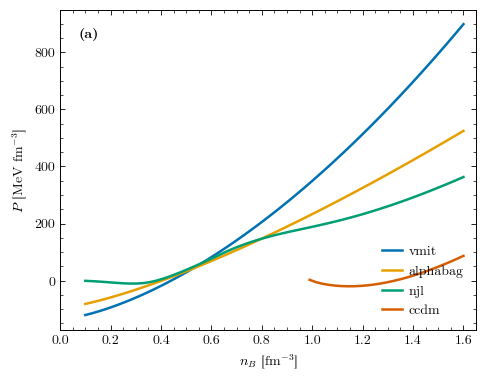

In [ ]:
fig, axes = paper_grid("1x1", mode="centered", placeholder=False, aspect=1.3)
ax = axes.ravel()[0]

for (name, (matrix, n_B)), colour in zip(MATRIX.items(), OKAB_CAT):
    ax.plot(n_B, matrix["P"][0], color=colour, label=name)

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["P"])
ax.set_xlim(0.0, 1.65)
ax.legend(loc="lower right")
panel_label(ax, "(a)")

plt.show()

### Composition

The flavour fractions and the leptons, all four models on one panel. Colour is
the SPECIES and comes from `particle_style` — u blue, d orange, s green,
electrons grey — and linestyle is the MODEL, so the two legends name four
things each instead of one legend naming sixteen. `particle_style` also
returns a linestyle, the one that marks a multiplet in a hadronic composition
figure; here the multiplet is the same for every curve and the linestyle is
needed to say which functional produced it, so only the colour is taken.

Y_e is the one that separates these models: it is the electron fraction beta
equilibrium needs to neutralize whatever charge the flavour composition leaves
over, so a phase that sits close to Y_u = Y_d = Y_s barely needs electrons at
all and one far from it needs many. Muons would appear here as a `Y_mu-`
column in `njl` and `ccdm`; the flag is off (above), so the column is zero and
is dropped by the same threshold that drops any other empty curve.

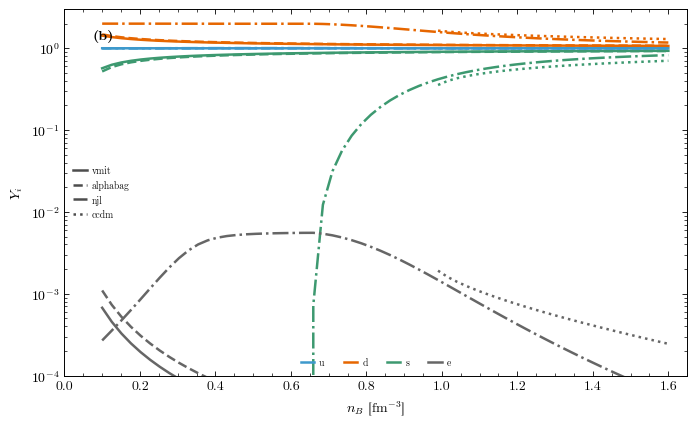

In [ ]:
# Linestyle is the model. Four of them, so the legend that names the models is
# read off this dict rather than from the curves.
MODEL_STYLE = {"vmit": "-", "alphabag": "--", "njl": "-.", "ccdm": ":"}

# The row column name -> the species name `particle_style` knows.
FRACTIONS = {"Y_u": "u", "Y_d": "d", "Y_s": "s",
             "Y_e": "e", "Y_mu-": "mu-"}

# Full page width: sixteen curves and two legends do not fit a single column.
fig, axes = paper_grid("1x1", mode="double", placeholder=False, aspect=1.7)
ax = axes.ravel()[0]

for name, (matrix, n_B) in MATRIX.items():
    for column, species_name in FRACTIONS.items():
        if column not in matrix:
            continue
        fraction = matrix[column][0]
        if np.nanmax(fraction) < 1e-4:      # below the panel, not worth a colour
            continue
        colour, _ = particle_style(species_name)
        ax.plot(n_B, fraction, color=colour, ls=MODEL_STYLE[name])

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"])
ax.set_xlim(0.0, 1.65)
ax.set_yscale("log")
ax.set_ylim(1e-4, 3.0)
# CMU Serif has no U+2212, so matplotlib's own mathtext log labels come out as
# hollow boxes below 1. `log_decades` is figure_style's protection for exactly
# that axis and is never removed (CLAUDE.md section 10).
log_decades(ax, axis="y")

# Two legends, built from proxy lines: one says which colour is which species,
# the other which linestyle is which model.
species_keys = [plt.Line2D([], [], color=particle_style(s)[0], label=s)
                for s in ("u", "d", "s", "e")]
model_keys = [plt.Line2D([], [], color="0.3", ls=style, label=name)
              for name, style in MODEL_STYLE.items() if name in MATRIX]
ax.add_artist(ax.legend(handles=species_keys, loc="lower center", ncol=4,
                        fontsize="x-small"))
ax.legend(handles=model_keys, loc="center left", fontsize="x-small")
panel_label(ax, "(b)")

plt.show()

### Effective quark masses

The same colour-is-species, linestyle-is-model reading, and the panel shows two
genuinely different things rather than one quantity computed four ways.

* **`njl` and `ccdm` return a mass.** Their constituent masses come out of a
  gap equation solved at every point, so `M_u`, `M_d`, `M_s` are columns of the
  table and fall with density as chiral symmetry is restored. That falling
  curve is most of what those two models cost — it is why their per-point
  timings above are tens to hundreds of times the bag models'.
* **`vmit` and `alphabag` return no mass column at all.** They have no gap
  equation: the quark masses are current masses carried on the parameter
  object and are the same number at every density. What is drawn for them is
  therefore `par.m_u`, `par.m_d`, `par.m_s`, read from the parameters, and the
  flat lines are shown rather than omitted because a flat line IS the physical
  statement — alphaBag's u and d sit at exactly zero and are off the bottom of
  a log axis, which is the same statement again.

The two are not interchangeable and the panel does not pretend they are: one
set of curves is a solved quantity and the other is an input.

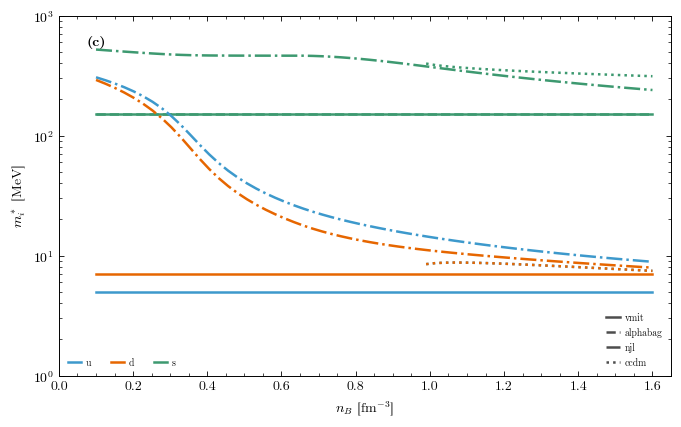

In [ ]:
fig, axes = paper_grid("1x1", mode="double", placeholder=False, aspect=1.7)
ax = axes.ravel()[0]

for name, (matrix, n_B) in MATRIX.items():
    for flavour in ("u", "d", "s"):
        column = f"M_{flavour}"
        if column in matrix:
            mass = matrix[column][0]                 # solved: the gap equation
        else:
            # No gap equation in this functional; the mass is the parameter.
            mass = np.full(n_B.shape,
                           getattr(PARAMS[name], f"m_{flavour}"))
        colour, _ = particle_style(flavour)
        ax.plot(n_B, mass, color=colour, ls=MODEL_STYLE[name])

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$m^*_i$ [MeV]")
ax.set_xlim(0.0, 1.65)
ax.set_yscale("log")
ax.set_ylim(1.0, 1e3)
log_decades(ax, axis="y")

flavour_keys = [plt.Line2D([], [], color=particle_style(f)[0], label=f)
                for f in ("u", "d", "s")]
ax.add_artist(ax.legend(handles=flavour_keys, loc="lower left", ncol=3,
                        fontsize="x-small"))
ax.legend(handles=model_keys, loc="lower right", fontsize="x-small")
panel_label(ax, "(c)")

plt.show()

## The njl parametrizations, side by side

`eos.njl.PUBLISHED_SETS` ships three, and at `csc=False` they are **not**
three independent points: the diquark coupling `eta_D` only enters the
pairing sector, so with the gaps off `kunkel` differs from `rkh` by its
vector coupling and by nothing else. What separates the three here is
therefore one sector — how the model carries vector repulsion:

* **rkh** — the RKH vacuum fit (Rehberg, Klevansky, Huefner, PRC 53, 410),
  `eta_V = 0`: no vector repulsion at all. `Sigma_V` is identically zero.
* **kunkel** — `eta_D = 1.45, eta_V = 0.7`, the constant-coupling form, so
  `Sigma_V` grows linearly with quark density. `eta_D` is inert at
  `csc=False`; it is what makes this set a strong-coupling point once
  `csc=True`.
* **gluon_exchange** — `G_V = G_V0/[1 + 8 k_F^2/(9 M_g^2)]`, a coupling that
  is a FUNCTION of the state, so `Sigma_V` saturates instead of running away.

The tier-1 vacuum numbers (Lambda, G_S Lambda^2, K Lambda^5, the current
masses) are the same in all three, so the vacuum masses and the whole chiral
sector start identical and separate only where the density does.

NJL has no meson mean fields — it is a contact interaction, and the only
field-like quantity it carries is `Sigma_V`, the vector self-energy that
shifts `mu*_j = mu_j - Sigma_V`. The condensates phi_f are the model's other
"field", and they are the constituent masses of the mass figure restated,
since `M_f = m_f - 4 G_S phi_f + 2 K phi_g phi_h`.

Colour is the SET in every figure, because comparing parametrizations is what
these are for; the species or field is the linestyle.

**The mass and composition figures come out degenerate, and that is the
result.** At fixed n_B in beta equilibrium the three sets agree on the
constituent masses, on every Y_i and on mu_C to 1e-14, and disagree on P, eps
and mu_B. Sigma_V is FLAVOUR-BLIND -- it shifts every mode by the same
amount -- so it cancels out of mu_C = mu_d - mu_u, which is what beta
equilibrium and neutrality close the composition with; and the condensates
that set M_f are functions of the densities, which the density axis has
already fixed. A vector coupling in this model buys stiffness and nothing
else, which is exactly why it is the knob a hybrid-star study turns.

In [ ]:
NJL_SETS = ("rkh", "kunkel", "gluon_exchange")
NJL_NB = np.linspace(0.2, 1.8, 80)      # above the chiral transition, into the
                                        # density a hybrid star's core reaches
NJL_FLAGS = njl.SpeciesFlags(csc=False)  # unpaired: no gaps, so eta_D is inert

njl_lines = {}
print("=== njl published sets, beta_eq_neutrinoless, T = 0, unpaired ===")
for name in NJL_SETS:
    par = njl.Parameters.named(name)
    table = njl.eos_table(par, "beta_eq_neutrinoless", NJL_FLAGS,
                          {"nB": NJL_NB, "T": np.array([0.0])})
    rows = njl_rows_from_result(table)
    njl_lines[name] = (par, rows)
    print(f"  [{name:15s}] {len(rows):3d}/{len(NJL_NB)} points   "
          f"eta_D={par.eta_D:4.2f} eta_V={par.eta_V:4.2f} "
          f"form={par.vector_form}")

# The matrices once, so each figure below is a plot and not another solve.
njl_matrix = {name: matrix_from_rows(rows)
              for name, (par, rows) in njl_lines.items()}

FLAVOUR_LS = {"u": "-", "d": "--", "s": "-."}

# The sets lie exactly on top of each other in the mass and composition
# figures, so they are drawn thick to thin. A coincidence has to be VISIBLE as
# a coincidence; drawn at one width the last curve hides the others and the
# figure reads as a missing result.
NJL_WIDTHS = (3.0, 1.8, 0.9)

# One figure per quantity. `single` is the one-column PRD width, which is what
# a figure carrying a single panel is for.
def njl_figure():
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    return fig, axes.ravel()[0]


def njl_style_legend(axis, entries, **kw):
    """A legend naming what the LINESTYLES mean, in neutral grey."""
    return axis.legend(handles=[plt.Line2D([], [], color="0.3", ls=s, label=n)
                                for n, s in entries], **kw)

=== njl published sets, beta_eq_neutrinoless, T = 0, unpaired ===
  [rkh            ]  80/80 points   eta_D=0.75 eta_V=0.00 form=constant
  [kunkel         ]  80/80 points   eta_D=1.45 eta_V=0.70 form=constant
  [gluon_exchange ]  80/80 points   eta_D=0.75 eta_V=0.00 form=gluon_exchange


### njl — pressure

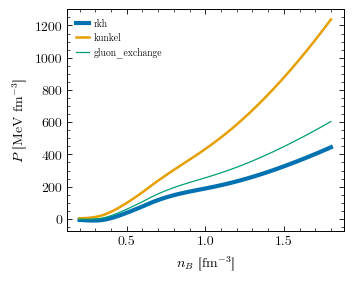

In [ ]:
fig, ax = njl_figure()
for (name, (matrix, axs)), colour, width in zip(njl_matrix.items(), OKAB_CAT,
                                                NJL_WIDTHS):
    ax.plot(axs["nB"], matrix["P"][0], color=colour, lw=width, label=name)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["P"])
ax.legend(loc="upper left", fontsize="x-small")
plt.show()

### njl — constituent masses

From the gap equation at every point, so these are solved quantities. All
three sets coincide; the widths are what makes that legible.

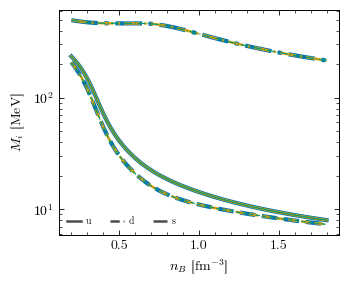

In [ ]:
fig, ax = njl_figure()
for (name, (matrix, axs)), colour, width in zip(njl_matrix.items(), OKAB_CAT,
                                                NJL_WIDTHS):
    for flavour, style in FLAVOUR_LS.items():
        ax.plot(axs["nB"], matrix[f"M_{flavour}"][0], color=colour, ls=style,
                lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$M_i$ [MeV]")
ax.set_yscale("log")
log_decades(ax, axis="y")
njl_style_legend(ax, FLAVOUR_LS.items(), loc="lower left", ncol=3,
                 fontsize="x-small")
plt.show()

### njl — composition

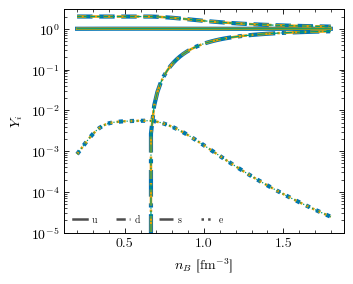

In [ ]:
fig, ax = njl_figure()
for (name, (matrix, axs)), colour, width in zip(njl_matrix.items(), OKAB_CAT,
                                                NJL_WIDTHS):
    for flavour, style in FLAVOUR_LS.items():
        ax.plot(axs["nB"], matrix[f"Y_{flavour}"][0], color=colour, ls=style,
                lw=width)
    ax.plot(axs["nB"], matrix["Y_e"][0], color=colour, ls=":", lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"])
ax.set_yscale("log")
ax.set_ylim(1e-5, 3.0)
log_decades(ax, axis="y")
njl_style_legend(ax, list(FLAVOUR_LS.items()) + [("e", ":")],
                 loc="lower left", ncol=4, fontsize="x-small")
plt.show()

### njl — the vector self-energy

The one field-like quantity NJL carries. `n_q` is the QUARK density in
natural units, three times n_B converted through hc^3; `vector_self_energy`
is a coupling evaluated on the state rather than a stored number, so it is
recomputed here instead of read from a column.

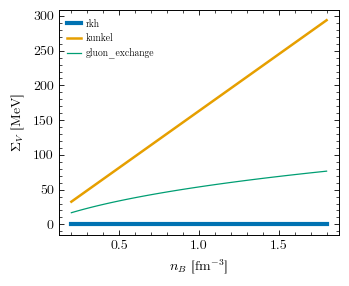

In [ ]:
fig, ax = njl_figure()
for (name, (par, rows)), colour, width in zip(njl_lines.items(), OKAB_CAT,
                                              NJL_WIDTHS):
    n_B = njl_matrix[name][1]["nB"]
    sigma_V = np.array([vector_self_energy(par, 3.0 * float(n) * hc3)
                        for n in n_B])
    ax.plot(n_B, sigma_V, color=colour, lw=width, label=name)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$\Sigma_V$ [MeV]")
ax.legend(loc="upper left", fontsize="x-small")
plt.show()

## The ccdm parametrizations, side by side

`eos.ccdm.PUBLISHED_SETS` ships four, and unlike njl's they are not one knob
seen three ways — each moves a different part of the functional:

* **baseline** — the specification's own set, `B_g^(1/4) = 150 MeV`,
  `m_sigma = 550 MeV`, `g_q = 3.0`. The shipped default.
* **novector** — the same with `gbar_omega = 0`: the L1 -> L0 reduction, the
  vector meson switched off at its coupling rather than by a flag (CLAUDE.md
  section 4 — a sector the model already carries a coupling for gets no
  flag).
* **dressed** — `q = 1`, which dresses the DIQUARK coupling,
  `G_D -> G_D/chi^q`. With `csc=False` there is no diquark condensate, so
  `G_D` never enters and this set is **bit-identical to baseline here** —
  every column agrees to exactly 0.0. That is not a defect and not a
  duplicate entry: it is the same structural fact as `njl`'s `eta_D`, and it
  means an unpaired comparison of "all four sets" is really a comparison of
  three. Turn `csc=True` and it separates.
* **stiff** — `B_g^(1/4) = 190 MeV`, a larger gluon-condensate bag. A bigger
  bag costs more to open, so this set's **deconfinement onset moves up** and
  its line starts well inside the axis. That is the model speaking, not a
  solver failure, and the counts printed below say where each one begins.

`novector` separates from `baseline` in P, `omega_0` and `Sigma_R` and in
NOTHING else — the masses, every Y_i and the two confining fields agree to
1e-12. The vector field is flavour-blind, so it cancels out of the
beta-equilibrium condition that fixes the composition, and at fixed n_B the
scalar sector is already determined. Only `stiff`, which moves the bag
itself, changes the composition and the fields.

**This model does have mean fields**, which is the difference from njl, and
they are columns of the table rather than something to recompute:

* `sigma`, `zeta` [MeV] — the non-strange and strange scalar condensates.
  `M*_(u,d) = (g_q sigma + m_q)/chi` and `M*_s = (g_s zeta + m_s)/chi`, so
  those two and the dielectric together ARE the effective-mass figure.
* `omega_0` [MeV] — the vector field, and `Sigma_R` [MeV] the rearrangement
  self-energy that rides with it (it enters mu and P, never eps — section 8).
* `phi_bar` — the confining scalar, dimensionless.
* `chi_diel` = (1 - phi_bar^4)^p — the dielectric function. It is named with
  a suffix because `chi` is already the shared column name for the
  mixed-phase quark volume fraction, which here is identically 1.

`branch` is reported per point: the enumeration chooses between the
`restored` and `partial` chiral branches by free energy, and a set can change
branch part-way up the density axis.

In [ ]:
CCDM_SETS = ("baseline", "novector", "dressed", "stiff")
CCDM_NB = np.linspace(0.8, 2.0, 40)      # starts below every onset, so the
                                         # onsets themselves are in the figures
CCDM_FLAGS = ccdm.SpeciesFlags(csc=False)

ccdm_lines = {}
print("=== ccdm published sets, beta_eq_neutrinoless, T = 0, unpaired ===")
for name in CCDM_SETS:
    par = ccdm.Parameters.named(name)
    table = ccdm.eos_table(par, "beta_eq_neutrinoless", CCDM_FLAGS,
                           {"nB": CCDM_NB, "T": np.array([0.0])})
    rows = ccdm_rows_from_result(table)
    ccdm_lines[name] = (par, rows)
    if rows:
        branches = sorted({row["branch"] for row in rows})
        print(f"  [{name:9s}] {len(rows):3d}/{len(CCDM_NB)} points, onset at "
              f"n_B = {rows[0]['n_B']:.3f} fm^-3   branches: {branches}")
    else:
        # A set with no deconfined phase anywhere on this axis is a statement
        # about the set, and is printed rather than silently absent.
        print(f"  [{name:9s}]   0/{len(CCDM_NB)} points: no deconfined phase "
              f"on this density axis")

ccdm_matrix = {name: matrix_from_rows(rows)
               for name, (par, rows) in ccdm_lines.items() if rows}

# Thick to thin, so a set lying exactly on another is VISIBLE as a coincidence:
# `dressed` sits on `baseline` everywhere, `novector` on it in all but the
# pressure and vector figures.
CCDM_WIDTHS = (3.2, 2.2, 1.4, 0.8)


def ccdm_figure():
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    return fig, axes.ravel()[0]


def ccdm_curves():
    """(name, matrix, n_B, colour, width) for every set that solved."""
    for (name, (matrix, axs)), colour, width in zip(ccdm_matrix.items(),
                                                    OKAB_CAT, CCDM_WIDTHS):
        yield name, matrix, axs["nB"], colour, width

=== ccdm published sets, beta_eq_neutrinoless, T = 0, unpaired ===
  [baseline ]  34/40 points, onset at n_B = 0.985 fm^-3   branches: ['partial', 'restored']
  [novector ]  34/40 points, onset at n_B = 0.985 fm^-3   branches: ['partial', 'restored']
  [dressed  ]  34/40 points, onset at n_B = 0.985 fm^-3   branches: ['partial', 'restored']
  [stiff    ]  22/40 points, onset at n_B = 1.354 fm^-3   branches: ['partial', 'restored']


### ccdm — pressure

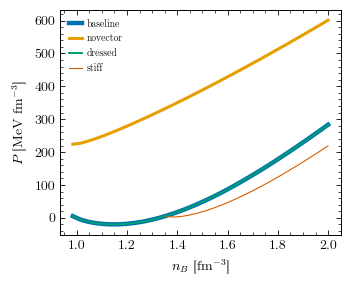

In [ ]:
fig, ax = ccdm_figure()
for name, matrix, n_B, colour, width in ccdm_curves():
    ax.plot(n_B, matrix["P"][0], color=colour, lw=width, label=name)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["P"])
ax.legend(loc="upper left", fontsize="x-small")
plt.show()

### ccdm — effective masses

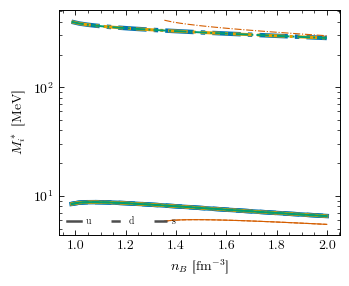

In [ ]:
fig, ax = ccdm_figure()
for name, matrix, n_B, colour, width in ccdm_curves():
    for flavour, style in FLAVOUR_LS.items():
        ax.plot(n_B, matrix[f"M_{flavour}"][0], color=colour, ls=style, lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$M^*_i$ [MeV]")
ax.set_yscale("log")
log_decades(ax, axis="y")
njl_style_legend(ax, FLAVOUR_LS.items(), loc="lower left", ncol=3,
                 fontsize="x-small")
plt.show()

### ccdm — composition

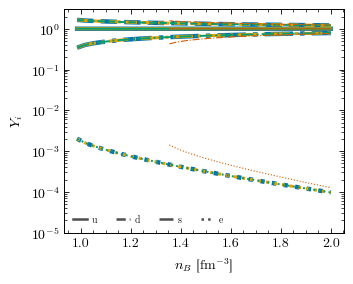

In [ ]:
fig, ax = ccdm_figure()
for name, matrix, n_B, colour, width in ccdm_curves():
    for flavour, style in FLAVOUR_LS.items():
        ax.plot(n_B, matrix[f"Y_{flavour}"][0], color=colour, ls=style, lw=width)
    ax.plot(n_B, matrix["Y_e"][0], color=colour, ls=":", lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"])
ax.set_yscale("log")
ax.set_ylim(1e-5, 3.0)
log_decades(ax, axis="y")
njl_style_legend(ax, list(FLAVOUR_LS.items()) + [("e", ":")],
                 loc="lower left", ncol=4, fontsize="x-small")
plt.show()

### ccdm — the confining fields

`phi_bar` is the confining scalar and `chi = (1 - phi_bar^4)^p` the
dielectric it drives. Both are dimensionless, which is why they share a
figure: chi -> 0 is the confined end, where a quark's effective mass diverges.

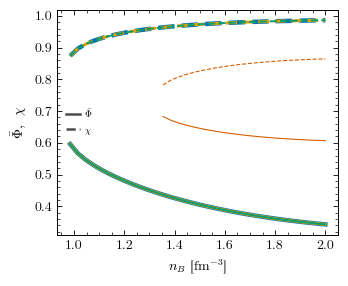

In [ ]:
fig, ax = ccdm_figure()
for name, matrix, n_B, colour, width in ccdm_curves():
    ax.plot(n_B, matrix["phi_bar"][0], color=colour, ls="-", lw=width, label=name)
    ax.plot(n_B, matrix["chi_diel"][0], color=colour, ls="--", lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$\bar{\Phi}$,  $\chi$")
njl_style_legend(ax, [(r"$\bar{\Phi}$", "-"), (r"$\chi$", "--")],
                 loc="center left", fontsize="x-small")
plt.show()

### ccdm — the scalar fields

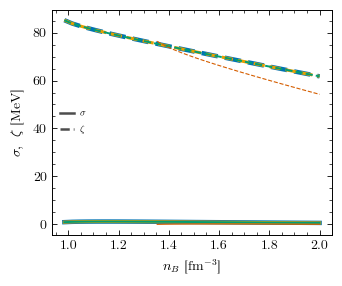

In [ ]:
fig, ax = ccdm_figure()
for name, matrix, n_B, colour, width in ccdm_curves():
    ax.plot(n_B, matrix["sigma"][0], color=colour, ls="-", lw=width, label=name)
    ax.plot(n_B, matrix["zeta"][0], color=colour, ls="--", lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$\sigma$,  $\zeta$ [MeV]")
njl_style_legend(ax, [(r"$\sigma$", "-"), (r"$\zeta$", "--")],
                 loc="center left", fontsize="x-small")
plt.show()

### ccdm — the vector field and its rearrangement

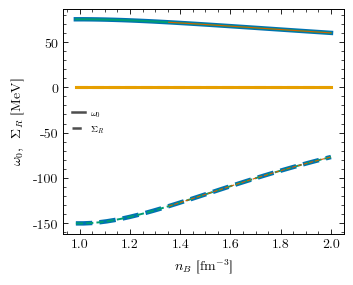

In [ ]:
fig, ax = ccdm_figure()
for name, matrix, n_B, colour, width in ccdm_curves():
    ax.plot(n_B, matrix["omega_0"][0], color=colour, ls="-", lw=width, label=name)
    ax.plot(n_B, matrix["Sigma_R"][0], color=colour, ls="--", lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$\omega_0$,  $\Sigma_R$ [MeV]")
njl_style_legend(ax, [(r"$\omega_0$", "-"), (r"$\Sigma_R$", "--")],
                 loc="center left", fontsize="x-small")
plt.show()

### Why switching the vector OFF makes ccdm stiffer

The pressure figure looks backwards: `novector` sits several hundred
MeV/fm^3 ABOVE `baseline`, so removing a repulsive vector meson appears to
stiffen the matter. It does, and the reason is the rearrangement term rather
than the field.

`eos.ccdm.couplings` makes the vector coupling a FUNCTION of the density,

    g_omega(n_B) = gbar_omega / [1 + (n_B/n_c)^2] ,

a repulsion that dies off at high density — which is what keeps the sound
speed off the causal limit without a hand-placed ceiling. With `n_c = 1`
fm^-3 it falls steeply: g_omega = 3.20 at n_B = 0.5 and 0.80 at 2.0. A
coupling that FALLS has `dg_omega/dn_B < 0`, and the rearrangement
self-energy is built from exactly that derivative,

    Sigma_R = (dg_omega/dn_B) omega_0 n_B  <  0 .

So the vector sector contributes to the two thermodynamic quantities
differently, which is the whole content of "Sigma_R enters mu and P, never
eps" (CLAUDE.md section 8):

    eps :  + W                    with W = (1/2) m_omega^2 omega_0^2
    P   :  + W  +  n_q Sigma_R

and at these densities the rearrangement piece is about 2.5x the field
energy and negative, so the sector's NET contribution to the pressure is
negative. Deleting it therefore raises P. The cell below checks that
arithmetic against the two solved tables rather than asserting it: the
predicted differences reproduce the observed ones to the last printed digit.

None of this is a consistency failure — `eos/ccdm/verify` finds Euler at
7e-16 and n = dP/dmu_B at 1.5e-5 on these same states. It is what a strongly
density-dependent coupling does, and it is why `novector` is the reduction
the verify suite uses: the two differ by a term that is easy to get wrong and
whose sign is not the one intuition supplies.

In [ ]:
BASE = ccdm.Parameters.named("baseline")

print(f"g_omega(n_B) = {BASE.gbar_omega} / [1 + (n_B/{BASE.n_c})^2],  "
      f"m_omega = {BASE.m_omega} MeV\n")
print(f"{'n_B':>5} {'g_omega':>8} {'W':>9} {'n_q*Sig_R':>10} "
      f"{'dP obs':>9} {'dP pred':>9} {'deps obs':>9} {'deps pred':>10}")

base_rows = {round(row["n_B"], 6): row for row in ccdm_lines["baseline"][1]}
novec_rows = {round(row["n_B"], 6): row for row in ccdm_lines["novector"][1]}

for key in sorted(base_rows):
    if key not in novec_rows:
        continue
    base, novec = base_rows[key], novec_rows[key]
    # W is the vector field energy, which eps and P both carry; n_q Sigma_R is
    # the rearrangement, which only P carries. Removing the sector removes W
    # from eps, and W + n_q Sigma_R from P.
    W = 0.5 * BASE.m_omega ** 2 * base["omega_0"] ** 2 / hc3
    rearrangement = 3.0 * key * base["Sigma_R"]
    if abs(key - round(key, 1)) > 1e-9:      # print a readable subset
        continue
    print(f"{key:5.2f} {vector_coupling(BASE, key * hc3):8.4f} {W:9.2f} "
          f"{rearrangement:10.2f} {novec['P'] - base['P']:9.2f} "
          f"{-(W + rearrangement):9.2f} {novec['eps'] - base['eps']:9.2f} "
          f"{-W:10.2f}")

g_omega(n_B) = 4.0 / [1 + (n_B/1.0)^2],  m_omega = 783.0 MeV

  n_B  g_omega         W  n_q*Sig_R    dP obs   dP pred  deps obs  deps pred
 1.20   1.6393    218.25    -515.21    296.96    296.96   -218.25    -218.25
 1.60   1.1236    182.27    -524.27    342.01    342.01   -182.27    -182.27
 2.00   0.8000    144.37    -462.00    317.62    317.62   -144.37    -144.37


## The two transitions, seen at fixed mu_B

Everything above this point was solved at fixed **density**, and a
fixed-density sweep cannot show a first-order transition: it walks straight
through the region where the branch exists but is not the favoured state,
which is why `ccdm`'s table reports an "onset" near 1 fm^-3 that is not where
quark matter actually takes over. A transition is a statement about which
branch has the LOWER free energy, and at T = 0 that is a comparison of
pressures at equal potentials — so it has to be made at fixed mu_B.

`eos.ccdm.thermodynamics.thermo_from_mu` is the surface for it. It closes the
model's internal system (the four fields, the gaps, colour neutrality) at
declared potentials in ONE declared branch, and the branch list at fixed
potential carries one entry the density list cannot:

    POTENTIAL_BRANCHES = ("confined", "restored", "partial")
    DENSITY_BRANCHES   =             ("restored", "partial")

`confined` is absent from the density list on purpose — with the dielectric
closed the quarks are not in the medium at all, so n_B = 0 identically and no
nonzero-density row can be met. At fixed mu_B it is exactly the branch that
describes the vacuum, and without it there is no transition to see.

**The two order parameters.**

* **chiral** — `sigma`, the non-strange scalar condensate. It sits at its
  vacuum value sigma_0 = f_pi = 93 MeV in the broken phase and falls to
  ~0 when chiral symmetry is restored. `zeta` is its strange partner and does
  NOT restore, which is the 't Hooft-like statement that the strange
  condensate survives: it moves from 94.0 to ~64 MeV over the whole scan.
* **deconfinement** — the dilaton. `Phi = phi_bar^4` is the gluon condensate
  in units of its vacuum value and `chi = (1 - Phi)^p` is the dielectric, the
  medium's transparency to colour. Confined is `phi_bar = 1`, `chi = 0`,
  where `M*_i = (g sigma + m)/chi` diverges and no quark is in the medium;
  deconfined is `phi_bar < 1`, `chi -> 1`.

The slice is **mu_C = 0**, T = 0, unpaired. That is the standard plane for a
chiral/deconfinement phase diagram and it is NOT beta equilibrium, which is
why the transition density here differs from the beta-equilibrium onset the
tables above report: `thermo_from_mu` takes mu_C as an input rather than
solving for it, so imposing neutrality would be an outer solve on top.

In [ ]:
MU_B = np.arange(1300.0, 1701.0, 5.0)       # MeV, across the transition
MU_C = 0.0                                   # the slice; NOT beta equilibrium
PAR_TRANSITION = ccdm.Parameters.default()


def transition_record(mu, state):
    return dict(mu_B=float(mu), P=state.P, n_B=state.n_B,
                sigma=state.sigma, zeta=state.zeta,
                phi_bar=state.Phi ** 0.25, chi=state.chi)


# One record per branch per potential. Non-convergence is a return value, so a
# branch that has no solution at this mu_B is simply absent from its list --
# below the transition the deconfined branch genuinely does not exist.
#
# The two branches are traced differently, and the difference is not cosmetic.
# `confined` is cold-seeded at every potential: it is the vacuum, and it
# converges everywhere. `restored` is walked DOWNWARDS from the top of the
# range with the previous solution as the seed, because a cold seed finds it at
# only 30 of 71 potentials on this slice and the ones it finds below the
# transition are the barrier root (n_B ~ 0.06 fm^-3, sigma ~ 47 MeV) rather
# than the minimum. Following one seed down is what makes the curve a BRANCH:
# it then ends where the branch ends, and the non-convergence there is the
# physics -- no deconfined state exists at that potential -- rather than a
# solver setting.
transition_scan = {"confined": [], "restored": []}
mu_branch_end = None

for mu in MU_B:
    state, ok, err = thermo_from_mu(PAR_TRANSITION, float(mu), MU_C, 0.0, 0.0,
                                    branch="confined")
    if ok:
        transition_scan["confined"].append(transition_record(mu, state))

seed = None
for mu in MU_B[::-1]:
    state, ok, err, x = thermo_from_mu(PAR_TRANSITION, float(mu), MU_C, 0.0,
                                       0.0, branch="restored", x0=seed,
                                       return_state=True)
    if not ok:
        mu_branch_end = float(mu)
        break
    seed = x
    transition_scan["restored"].append(transition_record(mu, state))
transition_scan["restored"].reverse()

# The transition is where the deconfined pressure overtakes the confined one.
# Both are read from the scan rather than assumed: the confined branch is the
# vacuum and its pressure is zero, but saying so is the check, not the input.
#
# On this slice the overtaking happens at the deconfined branch's own lower
# ENDPOINT rather than at a crossing of two curves that both continue: the
# branch ceases to exist while its pressure is still comfortably positive, so
# the first potential at which it exists is already the first at which it wins.
# That is the fixed-density back-bending seen from the other side -- mu_B has a
# minimum along the deconfined branch, so below that minimum there is no
# deconfined root at all.
confined = {r["mu_B"]: r for r in transition_scan["confined"]}
deconfined = {r["mu_B"]: r for r in transition_scan["restored"]}
mu_transition = None
for mu in sorted(deconfined):
    if mu in confined and deconfined[mu]["P"] > confined[mu]["P"]:
        mu_transition = mu
        break

print(f"=== ccdm at mu_C = {MU_C} MeV, T = 0, unpaired ===")
print(f"confined branch solved at {len(confined)}/{len(MU_B)} potentials, "
      f"deconfined at {len(deconfined)}/{len(MU_B)}")
if mu_branch_end is not None:
    print(f"  deconfined branch ends at mu_B = {mu_branch_end:.0f} MeV, "
          f"still at P = {deconfined[min(deconfined)]['P']:.1f} MeV/fm^3")
if mu_transition is None:
    print("  no crossing on this mu_B range")
else:
    lo = confined[mu_transition]
    hi = deconfined[mu_transition]
    print(f"  transition at mu_B = {mu_transition:.0f} MeV")
    print(f"    n_B      {lo['n_B']:8.4f} -> {hi['n_B']:8.4f} fm^-3   "
          f"({hi['n_B'] / 0.16:.2f} n_sat)")
    print(f"    sigma    {lo['sigma']:8.3f} -> {hi['sigma']:8.3f} MeV   "
          f"(chiral)")
    print(f"    zeta     {lo['zeta']:8.3f} -> {hi['zeta']:8.3f} MeV   "
          f"(strange, does NOT restore)")
    print(f"    phi_bar  {lo['phi_bar']:8.4f} -> {hi['phi_bar']:8.4f}       "
          f"(deconfinement)")
    print(f"    chi      {lo['chi']:8.4f} -> {hi['chi']:8.4f}")
    print("  both order parameters jump at the SAME mu_B: in this model "
          "chiral restoration\n  and deconfinement are one first-order "
          "transition, not two.")


def transition_axes(ylabel):
    """One panel with the transition marked, shared by the two figures."""
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    ax = axes.ravel()[0]
    if mu_transition is not None:
        ax.axvline(mu_transition, color="0.6", lw=0.8, ls=":", zorder=0)
    ax.set_xlabel(r"$\mu_B$ [MeV]")
    ax.set_ylabel(ylabel)
    return fig, ax


def branch_curve(branch, key):
    rows = transition_scan[branch]
    return (np.array([r["mu_B"] for r in rows]),
            np.array([r[key] for r in rows]))

=== ccdm at mu_C = 0.0 MeV, T = 0, unpaired ===
confined branch solved at 81/81 potentials, deconfined at 56/81
  deconfined branch ends at mu_B = 1420 MeV, still at P = 21.4 MeV/fm^3
  transition at mu_B = 1425 MeV
    n_B        0.0000 ->   1.3047 fm^-3   (8.15 n_sat)
    sigma      93.000 ->    0.660 MeV   (chiral)
    zeta       94.045 ->   80.831 MeV   (strange, does NOT restore)
    phi_bar    1.0000 ->   0.5112       (deconfinement)
    chi        0.0000 ->   0.9317
  both order parameters jump at the SAME mu_B: in this model chiral restoration
  and deconfinement are one first-order transition, not two.


### The chiral order parameter

`sigma` holds at f_pi = 93 MeV on the confined branch and collapses to below
1 MeV the moment the deconfined branch takes over — a jump, not a crossover.
`zeta` drops but stays large: the strange condensate does not restore here.

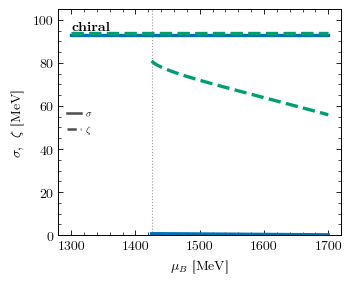

In [ ]:
fig, ax = transition_axes(r"$\sigma$,  $\zeta$ [MeV]")
for branch, style, width in (("confined", "-", 2.4), ("restored", "-", 2.4)):
    mu, sigma = branch_curve(branch, "sigma")
    mu, zeta = branch_curve(branch, "zeta")
    ax.plot(mu, sigma, color=OKAB_CAT[0], ls=style, lw=width)
    ax.plot(mu, zeta, color=OKAB_CAT[2], ls="--", lw=width)
ax.set_ylim(0.0, 105.0)
njl_style_legend(ax, [(r"$\sigma$", "-"), (r"$\zeta$", "--")],
                 loc="center left", fontsize="x-small")
panel_label(ax, "chiral")
plt.show()

### The deconfinement order parameter

The dilaton `phi_bar` sits at 1 on the confined branch — the medium is opaque,
`chi = 0`, and `M*_i` diverges, which is what "no quark in the medium" means
here — and drops to below 0.5 across the transition, taking `chi` from 0 to
~0.96. The two curves are one statement seen twice, since `chi = 1 -
phi_bar^4`; both are drawn because it is `phi_bar` that the field equations
solve for and `chi` that the masses divide by.

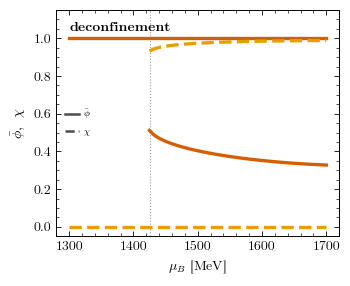

In [ ]:
fig, ax = transition_axes(r"$\bar{\phi}$,  $\chi$")
for branch in ("confined", "restored"):
    mu, phi = branch_curve(branch, "phi_bar")
    mu, chi = branch_curve(branch, "chi")
    ax.plot(mu, phi, color=OKAB_CAT[3], ls="-", lw=2.4)
    ax.plot(mu, chi, color=OKAB_CAT[1], ls="--", lw=2.4)
ax.set_ylim(-0.05, 1.15)
njl_style_legend(ax, [(r"$\bar{\phi}$", "-"), (r"$\chi$", "--")],
                 loc="center left", fontsize="x-small")
panel_label(ax, "deconfinement")
plt.show()

### The pressure crossing, and the density jump

The two panels above show WHAT changes across the transition; these two show
why it is one, and what it costs. At fixed potential the favoured branch is
the one with the LARGER pressure, so `P(mu_B)` is where the decision is made,
and the confined branch's flat zero is the scan's own output rather than an
assumption: with the dielectric closed there is no quark in the medium, so
`Omega` reduces to `U(1) + V(sigma_0, zeta_0)`, which the vacuum
normalisation sets to zero.

`n_B(mu_B)` is the same statement in the variable a table is built in. The
confined branch carries `n_B = 0` at EVERY potential -- it is the vacuum, not
a dilute phase -- so the density does not rise into the transition, it jumps
across it, from 0 to over 1 fm^-3 in one step. Nothing in between is a state
of this model, which is why a hybrid star built with `ccdm` takes its low
density half from a hadronic model through `eos.mixed` and never from the
confined branch.

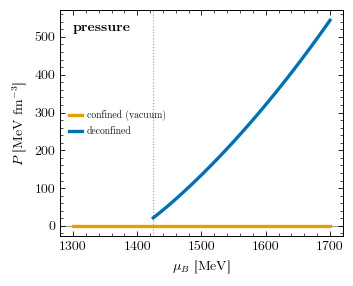

In [ ]:
fig, ax = transition_axes(LABELS["P"])
for branch, label, colour in (("confined", "confined (vacuum)", OKAB_CAT[1]),
                              ("restored", "deconfined", OKAB_CAT[0])):
    mu, P = branch_curve(branch, "P")
    ax.plot(mu, P, color=colour, lw=2.4, label=label)
ax.axhline(0.0, color="0.6", lw=0.8, zorder=0)
ax.legend(loc="center left", fontsize="x-small")
panel_label(ax, "pressure")
plt.show()

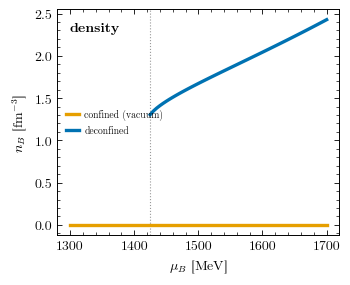

In [ ]:
fig, ax = transition_axes(LABELS["nB"])
for branch, label, colour in (("confined", "confined (vacuum)", OKAB_CAT[1]),
                              ("restored", "deconfined", OKAB_CAT[0])):
    mu, n_B = branch_curve(branch, "n_B")
    ax.plot(mu, n_B, color=colour, lw=2.4, label=label)
ax.legend(loc="center left", fontsize="x-small")
panel_label(ax, "density")
plt.show()

## A parameter scan you drive

ccdm, unpaired, T = 0, beta equilibrium. **Everything selectable is in the
next cell and nowhere else**: one parameter is swept, the rest are held, and
moving to the next study is two lines. The three the notes above call for:

    SWEEP = ("B_g_quarter", (150., 170., 190., 210., 230.))   # this one
    SWEEP = ("g_s",         (3., 4., 5., 6., 8.))             # then this
    SWEEP = ("gbar_omega",  (0., 2., 4., 6., 8., 10.))        # with n_c = 3
    SWEEP = ("n_c",         (1., 3., 10., float("inf")))     # and then this
    SWEEP = ("k_omega",     (0.5, 1., 2., 4.))                # the decay's shape
    SWEEP = ("p",           (0.5, 1., 2., 3.))                # the dielectric

That last one is the dielectric exponent, `chi = (1 - phi_bar^4)^p`, and it is
the knob on HOW FAST the dilaton melts. The anomaly argument fixes the FOURTH
POWER inside the bracket, because that combination is the gluon condensate; it
says nothing about the power of the bracket, and both endpoints -- `chi = 1`
at `phi_bar = 0`, `chi = 0` at `phi_bar = 1` -- hold for every `p > 0`. So `p`
moves only the approach between them, and that is what the sweep shows: at
`n_B = 1.5` fm^-3 the solved `phi_bar` is 0.598, 0.405, 0.176, 0.074 for
`p = 0.5, 1, 2, 3`, a factor of eight, while the density where `P` crosses
zero barely moves (1.35 -> 1.40 fm^-3 from `p = 1` to `p = 3`) and the lowest
density with a deconfined solution at all goes 1.00 -> 0.80. **`B_g_quarter`
is the onset knob and `p` is the profile knob** -- the bag sweep above moves
that floor 1.00 -> 1.65 fm^-3, which `p` never does. Below 1 it changes the
character instead of the numbers: at `p = 0.5` the pressure is positive over
the whole axis, so the phase is self-bound and there is no `P = 0` crossing
to be an onset. A structural choice declared per run rather than a sampled
one, and `q <= p` binds: `q = 1` needs `p >= 1`.

`n_c` is left at the model default 1.0 fm^-3 for the bag scan, since it only
scales a vector coupling the bag scan is not varying; set it to 3.0 in
`HELD` before the `gbar_omega` sweep, as planned.

**`n_c = inf` is the constant-coupling model, exactly** — it is the
`constvector` published set. `g_omega = gbar_omega/[1 + (n_B/n_c)^2]` returns
`gbar_omega`, and the rearrangement `Sigma_R = (dg/dn_B) omega_0 n_B` carries
`n_c^2` in its denominator, so it vanishes with it. No second code path.

READ dP/dn_B ON THIS SWEEP, not only the onset — and there is a closed-form
rule for where it goes wrong. The two vector terms of `P` are the field
energy and `Sigma_R n_q`, and together

    P_vec = (n_q^2/m_omega^2) g^2 [ 1/2 - k u^k/(1 + u^k) ] ,   u = n_B/n_c

so the vector sector starts REMOVING pressure once the coupling's
logarithmic slope passes -1/2, at `u > (2k - 1)^(-1/k)` = 0.577 for the
shipped `k = 2`. Worse, `P_vec` is already falling from `u = 0.363` (the
roots of `3u^4 - 8u^2 + 1 = 0` are 0.363 and 1.592). **Keep `0.363 n_c`
above the top of the density axis** and the sector is monotonic over it: for
a table reaching 2.6 fm^-3 that is `n_c >= 7.2` fm^-3. At `n_c = 3` with
`gbar_omega = 4` it is badly violated and `P` falls from the onset, reaching
`c_s^2 = -0.59` — mechanically unstable, not soft.

`k_omega` is the exponent of that decay, and unlike the 4 inside the
dielectric bracket (which the scale anomaly fixes) it is a modelling choice.
It is a weak lever on WHERE the turnover sits — the threshold above is 1.0,
0.577, 0.585, 0.615 for `k = 1, 2, 3, 4` — and a qualitative switch at
`k = 1/2`, at or below which the slope never reaches -1/2 and the vector
sector adds pressure at every density. The price is that so gentle a decay
never saturates the vector energy, which is what the density dependence was
for. At `gbar_omega = 4`, `n_c = 3` fm^-3 the same point that is unstable at
`k = 2` is monotonic at `k = 1` and at `k = 0.5`.

A larger bag pushes the deconfinement onset up (a bigger bag costs more to
open), so the density axis has to reach well past it or the stiffest sets
come back empty. The counts printed say where each one begins.

In [ ]:
CCDM_SETS = ("baseline", "novector", "dressed", "stiff")

In [ ]:
SWEEP = ("n_c", (0, 2, 4, 6, 8))

HELD = dict(B_g_quarter = 170.,
            g_q=3.0,          # pinned by the specification's section 10 table
            g_s=3.0,          # flavour-symmetric choice, prior 3-8
            m_sigma=550.0,    # held throughout
            gbar_omega=2.0,   # 0-10 in the later scan
            #n_c=float("inf")
            )          # 3.0 for that scan, then 1-3-10-20

SCAN_NB = np.linspace(0.60, 2.60, 41)
SCAN_FLAGS = ccdm.SpeciesFlags(csc=False)

scan_name, scan_values = SWEEP
scan = {}
print(f"=== ccdm, beta_eq_neutrinoless, T = 0, unpaired ===")
print(f"sweeping {scan_name} over {list(scan_values)}; held: {HELD}\n")
for value in scan_values:
    # The swept name is dropped from HELD rather than assumed absent from it:
    # `HELD` lists gbar_omega and n_c, so sweeping either of those would hand
    # `replace` the same keyword twice and raise before a single point is
    # solved. One dict comprehension, and every entry of the SWEEP menu works.
    held = {name: held_value for name, held_value in HELD.items()
            if name != scan_name}
    par = replace(ccdm.Parameters.default(), **held, **{scan_name: value})
    rows = ccdm_rows_from_result(ccdm.eos_table(
        par, "beta_eq_neutrinoless", SCAN_FLAGS,
        {"nB": SCAN_NB, "T": np.array([0.0])}))
    label = f"{scan_name} = {value:g}"
    if not rows:
        print(f"  [{label:22s}]   0/{len(SCAN_NB)} points: no deconfined "
              f"phase on this axis")
        continue
    scan[label] = (par, *matrix_from_rows(rows))
    print(f"  [{label:22s}] {len(rows):3d}/{len(SCAN_NB)} points, onset at "
          f"n_B = {rows[0]['n_B']:.3f} fm^-3 ({rows[0]['n_B']/0.16:.2f} n_sat)")


def scan_figure(ylabel):
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    ax = axes.ravel()[0]
    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(ylabel)
    return fig, ax


def scan_curves():
    """(label, par, matrix, n_B, colour) for every set that solved."""
    for (label, (par, matrix, axs)), colour in zip(scan.items(), OKAB_CAT):
        yield label, par, matrix, axs["nB"], colour

=== ccdm, beta_eq_neutrinoless, T = 0, unpaired ===
sweeping gbar_omega over [0, 2, 4, 6, 8]; held: {'B_g_quarter': 170.0, 'g_q': 3.0, 'g_s': 3.0, 'm_sigma': 550.0, 'n_c': inf}

  [gbar_omega = 0        ]  30/41 points, onset at n_B = 1.150 fm^-3 (7.19 n_sat)
  [gbar_omega = 2        ]  30/41 points, onset at n_B = 1.150 fm^-3 (7.19 n_sat)
  [gbar_omega = 4        ]  30/41 points, onset at n_B = 1.150 fm^-3 (7.19 n_sat)
  [gbar_omega = 6        ]  30/41 points, onset at n_B = 1.150 fm^-3 (7.19 n_sat)
  [gbar_omega = 8        ]  30/41 points, onset at n_B = 1.150 fm^-3 (7.19 n_sat)


### Pressure

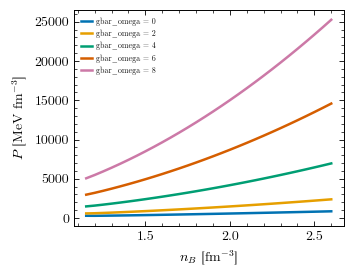

NameError: name 'FLAVOUR_LS' is not defined

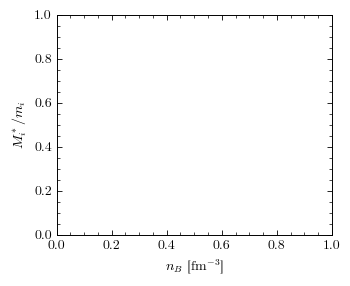

In [ ]:
fig, ax = scan_figure(LABELS["P"])
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(n_B, matrix["P"][0], color=colour, label=label)
ax.legend(loc="upper left", fontsize="xx-small")
plt.show()

fig, ax = scan_figure(r"$M^*_i / m_i$")
CURRENT = {"u": "m_u", "d": "m_d", "s": "m_s"}
for label, par, matrix, n_B, colour in scan_curves():
    for flavour, style in FLAVOUR_LS.items():
        m_current = getattr(par, CURRENT[flavour])
        ax.plot(n_B, matrix[f"M_{flavour}"][0] / m_current,
                color=colour, ls=style)
ax.set_yscale("log")
log_decades(ax, axis="y")
njl_style_legend(ax, FLAVOUR_LS.items(), loc="upper right", ncol=3,
                 fontsize="xx-small")
plt.show()

fig, ax = scan_figure(r"$\bar{\phi}$")
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(n_B, matrix["phi_bar"][0], color=colour, label=label)
ax.legend(loc="upper right", fontsize="xx-small")
plt.show()

fig, ax = scan_figure(r"$\sigma$,  $\zeta$ [MeV]")
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(n_B, matrix["sigma"][0], color=colour, ls="-", label=label)
    ax.plot(n_B, matrix["zeta"][0], color=colour, ls="--")
njl_style_legend(ax, [(r"$\sigma$", "-"), (r"$\zeta$", "--")],
                 loc="center left", fontsize="xx-small")
plt.show()

### The dilaton

`phi_bar` is the gluon condensate in units of its vacuum value, to the fourth
root: `Phi = phi_bar^4` and `chi = (1 - Phi)^p`. `phi_bar = 1` is the confined
vacuum and `phi_bar -> 0` the perturbative limit, so a curve falling with
density is the medium becoming transparent to colour.

### The scalar condensates

`sigma` is the non-strange condensate, near zero across this whole range —
the light sector is already chirally restored wherever a deconfined solution
exists. `zeta` is its strange partner and stays large: it does not restore.

### The dilaton effective potential, one curve per density

**The bare glue potential is the wrong thing to plot against density.**

    U(Phi) = B_g [ Phi (ln Phi - 1) + 1 ] ,   Phi = phi_bar^4

has no density in it at all — it is `B_g` times a fixed shape, zero at the
vacuum `Phi = 1` and equal to `B_g` at `Phi = 0`. One curve per n_B of *that*
would be one curve drawn five times.

What does depend on the density is the CONSTRAINED EFFECTIVE POTENTIAL: the
thermodynamic potential with the dilaton HELD at a chosen value and every
other field re-solved at it. Its stationary points are the model's solutions,
because the dilaton row of the internal system is exactly its derivative,

    R_1 = dOmega/dPhi = B_g ln Phi + p sum_f M*_f rho_s,f/(1 - Phi) = 0 ,

and its shape is what a first-order transition looks like: two minima that
exchange depth. That is the curve with a dot on it.

The other fields must be re-solved rather than frozen. Holding `sigma`,
`zeta` and `Sigma_V` at their solved values while moving `Phi` breaks
stationarity — `Sigma_V` is a function of the quark density, which `Phi`
changes — and the resulting curve has its minimum in the wrong place. Solving
rows R_2, R_3 and R_4 at each `Phi` is what makes the dot land on the
minimum, and where it does NOT land there the state is metastable, which is
a result rather than a defect.

**Read the dots.** At the low densities the solved state sits in the
SHALLOWER well: its mu_B is below the transition potential, so deconfined
matter exists there but is not the favoured phase — which is exactly why the
fixed-density "onset" reported by the tables above is not a transition. At
the higher densities the dot is the global minimum and the state is stable.
Omega is offset by its own value at the dot, so the dot sits at zero and any
part of a curve dipping BELOW zero is a deeper phase the solver did not take.

**What the deeper state at the confining end is, and what it is not.** The
open circle at `phi_bar = 1` is the confined vacuum, drawn from the exact
value `Omega = 0` rather than walked to: it lies at `-Omega_sol`, so the test
is one line of arithmetic — **the solved state is metastable iff its matter
pressure is negative**, since the vacuum's is zero. Below it the curve is not
drawn at all in the closing region, because the constrained solve stops
converging there and, worse, converges onto a DIFFERENT root once it does:
the vector row is a fixed-point equation in `Sigma_V`, and its second
solution here holds `Sigma_V` at +129 MeV and `n_B` at 0.319 fm^-3 for every
held dilaton, some 80 MeV/fm^3 below this branch. Earlier drafts of this cell
swept the whole grid and drew that family as a deep second well; it is not a
phase, it is a different family at a different density. `state.valid` does
not catch it — that flag is `M*_f > 0`, which it satisfies — so the curve is
traced OUTWARD from the solution and stopped where the branch ends.

**So should the solver "jump to the deeper minimum"?** At fixed density it
cannot, and the question is the wrong way round. The deeper state is the
vacuum, `n_B = 0`; there is no such thing as 1.2 fm^-3 of vacuum, which is
why `DENSITY_BRANCHES` excludes `confined` in the first place. Among the
branches that DO exist at a given density the solver already takes the
global minimum — `eos.ccdm.solver.solve` ranks every converged candidate by
`f = eps - T s`, the right potential at fixed density. A metastable segment
is real physics and is removed by a CONSTRUCTION against the phase that
replaces the vacuum in a star — Maxwell, Gibbs, or the eta-mixed phase of
`eos.mixed` — not by picking a different root here.

dilaton effective potential; 'metastable' = a deeper minimum exists
  [B_g_quarter = 150     ] n_B = 1.2: METASTABLE against the vacuum by 18.0 MeV/fm^3 (solved at phi_bar = 0.481)
  [B_g_quarter = 150     ] n_B = 1.2: branch traced over phi_bar = 0.050-0.502 (30/60 of the grid); it ends where the held-dilaton solve leaves it
  [B_g_quarter = 150     ] n_B = 1.6: branch traced over phi_bar = 0.050-0.393 (23/60 of the grid); it ends where the held-dilaton solve leaves it
  [B_g_quarter = 150     ] n_B = 2: branch traced over phi_bar = 0.050-0.346 (20/60 of the grid); it ends where the held-dilaton solve leaves it
  [B_g_quarter = 150     ] n_B = 2.4: branch traced over phi_bar = 0.050-0.331 (19/60 of the grid); it ends where the held-dilaton solve leaves it
  [B_g_quarter = 170     ] n_B = 1.2: METASTABLE against the vacuum by 15.7 MeV/fm^3 (solved at phi_bar = 0.624)
  [B_g_quarter = 170     ] n_B = 1.2: branch traced over phi_bar = 0.050-0.627 (38/60 of the grid); it ends where the he

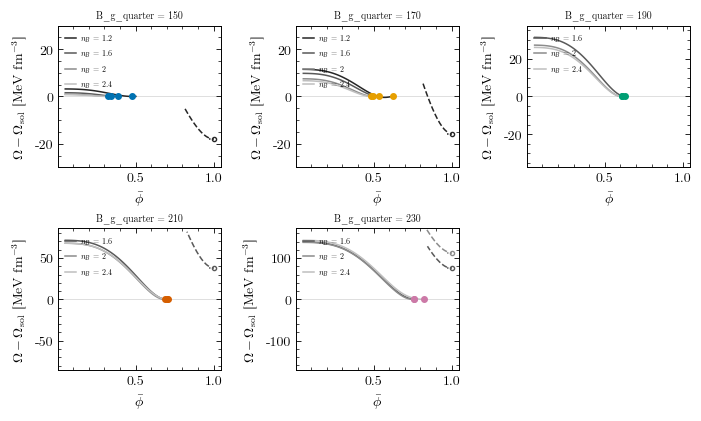

In [ ]:
POT_NB = (1.2, 1.6, 2.0, 2.4)          # densities to draw a curve for
PHI_GRID = np.linspace(0.05, 0.97, 60)  # the held dilaton values


def omega_at_phi(par, phi_bar, mu_B, mu_C, seed):
    """Omega with the dilaton HELD at phi_bar and the other fields solved.

    Returns (Omega [MeV^4], the solved (sigma, zeta, Sigma_V), M*_u, and
    whether it converged) so the caller can warm-start the next point, test
    that it is still on the branch, AND discard the ones that did not solve.
    Rows R_2, R_3 and R_4 of
    `eos.ccdm.thermodynamics.internal_rows`, each divided by the scale
    `internal_scales` gives it.

    CONVERGENCE HAS TO BE TESTED HERE. Towards phi_bar -> 1 the dielectric
    closes, M*_f diverges as 1/(1 - Phi), and the sub-solve stops converging;
    the Omega it then returns is a numerical artefact that looks exactly like
    a second minimum. Reporting those as metastability would invent a phase.

    CONVERGENCE IS NOT ENOUGH BY ITSELF, and the caller has to walk outward
    from the solved dilaton rather than sweep a grid. Past the point where the
    branch ends this solve does not simply fail: it converges onto ANOTHER root
    of the same rows. Row R_4, Sigma_V = g_omega(n_B) 3 n_B/m_omega^2 + Sigma_R
    with n_B itself a function of Sigma_V through mu* = mu - Sigma_V, is a
    fixed-point equation with more than one solution, and the second one here
    sits at Sigma_V = +129 MeV with n_B pinned at 0.319 fm^-3 for EVERY held
    dilaton -- a different family, at a different density, whose Omega runs
    some 80 MeV/fm^3 below the branch. Drawn on the same curve it looks exactly
    like a deep second well. It is not one. `state.valid` does not catch it
    either: that flag is M*_f > 0, which this family satisfies.
    """
    d = par.derived
    scales = (abs(d.eps_sigma), abs(d.eps_zeta), max(abs(mu_B) / 3.0, 1.0))

    def residual(y):
        state = state_at(par, float(phi_bar) ** 4, y[0], y[1], y[2],
                         np.zeros(3), mu_B, mu_C, 0.0, 0.0, 0.0, 0.0,
                         branch="restored", pattern="unpaired")
        return [state.field_residual[i + 1] / scales[i] for i in range(3)]

    solution = root(residual, seed, method="hybr")
    state = state_at(par, float(phi_bar) ** 4, solution.x[0], solution.x[1],
                     solution.x[2], np.zeros(3), mu_B, mu_C, 0.0, 0.0, 0.0, 0.0,
                     branch="restored", pattern="unpaired")
    converged = bool(np.max(np.abs(residual(solution.x))) < 1.0e-8)
    return state.Omega, solution.x, float(state.M_star[0]), converged


n_panels = len(scan)
n_cols = min(3, n_panels)
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = paper_grid(f"{n_rows}x{n_cols}", mode="double", placeholder=False,
                       aspect=1.15)
flat = np.atleast_1d(axes).ravel()

print("dilaton effective potential; 'metastable' = a deeper minimum exists")
for panel, (label, par, matrix, n_B, colour) in zip(flat, scan_curves()):
    span = [25.0]              # the y-range, set by the DECONFINED curves
    for target, shade in zip(POT_NB, np.linspace(0.15, 0.75, len(POT_NB))):
        i = int(np.argmin(np.abs(n_B - target)))
        if abs(n_B[i] - target) > 0.06 or not np.isfinite(matrix["P"][0][i]):
            continue                      # that density is below this onset
        mu_B, mu_C = matrix["mu_B"][0][i], matrix["mu_C"][0][i]
        phi_solved = matrix["phi_bar"][0][i]

        # A warm start from the solved state, carried along the phi_bar grid.
        state, ok, _ = thermo_from_mu(par, mu_B, mu_C, 0.0, 0.0,
                                      branch="restored")
        if not ok:
            continue
        seed_0 = np.array([state.sigma, state.zeta, state.Sigma_V])

        def walk(grid, seed, closing=False):
            """Trace one family along `grid`, stopping where it ends.

            `closing` walks towards phi_bar = 1, and there M*_f = (g_f phi_f +
            m_f)/chi has to RISE: that is the confinement mechanism. A step
            that lowers it has left the branch for the cancellation family
            below, so the walk stops rather than drawing it.
            """
            reached, last_mass = [], 0.0
            for phi_bar in grid:
                value, trial, mass, ok_sub = omega_at_phi(par, phi_bar, mu_B,
                                                          mu_C, seed)
                if not ok_sub or (closing and mass < last_mass):
                    break
                reached.append((phi_bar, value))
                seed, last_mass = trial, mass   # only a solved point seeds on
            return reached

        # OUTWARD FROM THE SOLUTION, IN BOTH DIRECTIONS, AND STOP AT THE FIRST
        # POINT THAT DOES NOT SOLVE. Past that the constrained solve does not
        # merely fail: it lands on a DIFFERENT root and keeps returning values.
        # The one reachable here is the vector row's second solution, where
        # Sigma_V jumps from -20 to +129 MeV and n_B sticks at 0.319 fm^-3 for
        # EVERY held dilaton. Drawn on, it makes a well some 80 MeV/fm^3 deep
        # that is not a phase but a different family of solutions, at a
        # different density, plotted as though it continued this curve. Walking
        # outward and stopping is what keeps one curve one branch -- the same
        # rule the mu_B scan above traces the deconfined branch with.
        traced = sorted(walk(PHI_GRID[PHI_GRID < phi_solved][::-1], seed_0)
                        + walk(PHI_GRID[PHI_GRID > phi_solved], seed_0,
                               closing=True))

        # THE CONFINING SIDE IS A DIFFERENT FAMILY AND NEEDS THE VACUUM'S
        # SEED. Relaxing the deconfined fields at a held phi_bar near 1 does
        # not reach it: it follows a root where sigma tunes itself towards
        # -m_u/g_q so that the numerator of M*_u = (g_q sigma + m_u)/chi
        # cancels the closing chi and the quarks stay LIGHT while the medium
        # goes opaque -- the confinement mechanism defeated by a fine
        # cancellation. Its Omega runs up to 90 MeV/fm^3 below the branch and
        # looks exactly like a deep second well; the rising-M* test in `walk`
        # is what keeps it off the curve. Seeded from (sigma_0, zeta_0, 0) the
        # same rows give the confined family instead: sigma = sigma_0 = 93 MeV,
        # no quark in the medium, n_B = 0 at every held dilaton, ending on the
        # open circle at phi_bar = 1. THAT is the second minimum, and drawing
        # both is what makes "two minima that exchange depth" visible rather
        # than asserted.
        d = par.derived
        confined = walk(PHI_GRID[::-1], np.array([d.sigma_0, d.zeta_0, 0.0]))

        # Offset by Omega at the solved dilaton, so the dot sits at zero.
        at_dot, _, _, ok_dot = omega_at_phi(par, phi_solved, mu_B, mu_C,
                                            seed_0)
        if not ok_dot or not traced:
            continue
        phi_drawn = np.array([row[0] for row in traced])
        curve = (np.array([row[1] for row in traced]) - at_dot) / hc3
        panel.plot(phi_drawn, curve, color=str(shade), lw=1.1,
                   label=f"$n_B$ = {target:g}")
        if confined:
            panel.plot([row[0] for row in confined],
                       (np.array([row[1] for row in confined]) - at_dot) / hc3,
                       color=str(shade), lw=1.1, ls="--")
        panel.plot(phi_solved, 0.0, "o", color=colour, ms=4.0, zorder=5)
        span.append(float(np.abs(curve).max()))

        # THE CONFINED VACUUM IS AN EXACT NUMBER, not a limit of this grid. At
        # phi_bar = 1 the dielectric is shut, no quark is in the medium, and
        # Omega reduces to U(1) + V(sigma_0, zeta_0) = 0 by the vacuum
        # normalisation -- so on this offset axis it sits at -Omega_sol, i.e.
        # at the matter pressure of the solved state itself. Drawing it is
        # better than walking the grid to the edge, where the constrained solve
        # cannot follow (M* diverges), and it makes the test for metastability
        # exact and one-sided: THE STATE IS METASTABLE IFF ITS PRESSURE IS
        # NEGATIVE, because the vacuum's is zero.
        vacuum = -at_dot / hc3                  # MeV/fm^3
        panel.plot([PHI_GRID[-1], 1.0], [vacuum, vacuum], color=str(shade),
                   lw=1.1, ls=":")
        panel.plot(1.0, vacuum, "o", color=str(shade), ms=3.0,
                   markerfacecolor="none")

        if vacuum < 0.0:
            print(f"  [{label:22s}] n_B = {target:g}: METASTABLE against the "
                  f"vacuum by {-vacuum:.1f} MeV/fm^3 "
                  f"(solved at phi_bar = {phi_solved:.3f})")
        if curve.size and curve.min() < -1.0:
            where = phi_drawn[int(np.argmin(curve))]
            print(f"  [{label:22s}] n_B = {target:g}: a DECONFINED state "
                  f"{-curve.min():.1f} MeV/fm^3 deeper sits at "
                  f"phi_bar = {where:.3f}")
        print(f"  [{label:22s}] n_B = {target:g}: branch traced over "
              f"phi_bar = {phi_drawn[0]:.3f}-{phi_drawn[-1]:.3f} "
              f"({len(phi_drawn)}/{len(PHI_GRID)} of the grid); it ends where "
              f"the held-dilaton solve leaves it")

    # The confined family runs to +P of the solved state, which at the high
    # densities is several hundred MeV/fm^3 and would flatten everything else.
    # The scale is set by the deconfined curves and the confined ones leave the
    # top of the panel; where the vacuum matters -- when it is BELOW zero and
    # the state is metastable -- it is a small number and stays in frame.
    panel.set_ylim(-1.2 * max(span), 1.2 * max(span))
    panel.axhline(0.0, color="0.85", lw=0.6, zorder=0)
    panel.set_xlabel(r"$\bar{\phi}$")
    panel.set_ylabel(r"$\Omega - \Omega_{\rm sol}$ [MeV fm$^{-3}$]")
    panel.set_title(label, fontsize=7)
    panel.legend(loc="upper left", fontsize="xx-small")

for spare in flat[n_panels:]:
    spare.set_visible(False)

plt.show()